# 12. Sensitivity analysis

## Numerical experiments - Week 45/2025

_Boyan Mihaylov, MSc Computational Science (UVA/VU)_

The procedure presented below performs Bayesian Model Averaging (BMA) on the broad collection of models to
- assess their likelihood of representing the data (with its inherent variance),
- penalize overly complex models,
- assess the models' predictive capabilities
- and explore the combined predictive power of weighted combinations of models.

The aim is to obtain a list of models ranked by their pseudo-BMA weights, which evaluate predictive accuracy under uncertainty and are thus a better criterion than RMSE of model fits to data.

## Prerequisite libraries

In [1]:
using PyPlot
using Distributions
using QuasiMonteCarlo
using JLD2
using Revise

# include("../src/conversions.jl")
# include("../src/diffusion.jl")
# include("../src/setup.jl")
# include("../src/plotting.jl")
# include("../src/analysis.jl")
# include("../src/datautils.jl")
# include("../src/germstats.jl")

Revise.includet("../src/conversions.jl")
Revise.includet("../src/diffusion.jl")
Revise.includet("../src/setup.jl")
Revise.includet("../src/plotting.jl")
Revise.includet("../src/analysis.jl")
Revise.includet("../src/datautils.jl")
Revise.includet("../src/germstats.jl")

using .Conversions
using .Diffusion
using .Setup
using .Plotting
using .Analysis
using .DataUtils
using .GermStats

## 1. Parameter priors

The first step is to assume prior distributions of the model parameters, which encode the expectations of plausible parameter values before relating them to data.

### 1.1. Parameter summary

The free parameters in the germination models are:

- $P_s^\textrm{I}$ - the permeation coefficient of the inhibitor molecule through the cell wall;
- $P_s^\textrm{C}$ - the permeation coefficient of the inducer molecule (carbon source) through the cell wall;
- $K_\textrm{I}$ - the half-saturation constant of the inhibitor when directly blocking the inducing signal;
- $K_\textrm{I}^\Delta$ - the half-saturation constant of the inhibitor when shifting the induction threshold or permeability;
- $K_\textrm{C}^\Delta$ - the half-saturation constant of the inducer when shifting the inhibition threshold or permeability;
- $s$ - scaling factor of the permeability perturbation caused by the inducing signal;
- $b$ - scaling factor of the permeability perturbation caused by the inhibitory signal;
- $k_\textrm{I}$ - scaling factor of the induction threshold shift caused by the inhibitory signal;
- $k_\textrm{C}$ - scaling factor of the inhibition threshold shift caused by the inducing signal;
- $n$ - Hill exponent of the direct inhibition of the inducing signal;
- $\mu_\gamma$ - mean of the inhibition threshold;
- $\sigma_\gamma$ - standard deviation of the inhbition threshold;
- $\mu_\omega$ - mean of the induction threshold;
- $\sigma_\omega$ - standard deviation of the induction threshold;
- $\mu_\psi$ - mean of the initial inhibitor concentration in the spore;
- $\sigma_\psi$ - standard deviation of the initial inhibitor concentration in the spore.

Some of these parameters are independent of the type of carbon source, others are inducer-specific and therefore get a specific instance (with its own distribution) in each inducer case. The inducer-specific parameters are $P_s^\textrm{C}$, $K_\textrm{I}$, $K_\textrm{I}^\Delta$, $K_\textrm{C}^\Delta$, $s$, $k_\textrm{I}$, $k_\textrm{C}$, $n$, $\mu_\omega$, $\sigma_\omega$. On the other hand, $P_s^\textrm{I}$, $b$, $\mu_\gamma$, $\sigma_\gamma$, $\mu_\psi$ and $\sigma_\psi$ are general for all inducer cases.

### 1.2. Determining the priors

Since an exact quantification of the prior distributions is generally difficult to infer from literature, several approaches can be employed to narrow down the bounds, shape an scale of each parameter prior:

1. Use biologically plausible bounds and shapes wherever known.
2. If not known, use log-normal distributions within generously wide bounds, such that 95% of the distribution fall within the bounds.
3. Sample the parameter space, fit the Dantigny triplets to each parameter sample and inspect the distributions of the Dantigny triplets. If a large discrepancy is noticeable compared to recorded data (certain values of a parameter consistently yield unplausible $p_{\textrm{max}}$, $\tau_g$ or $\nu$), narrow down the bounds accordingly. (Prior predictive checks)

#### 1.2.1. Initial guesses

It has been shown that to achieve realistic inhibitor depletion within 4 hours, $P_s^\textrm{I}$ needs to be in the order of $10^{-9}\ \textrm{cm/s}$ to $10^{-7}\ \textrm{cm/s}$. However, inference from physical properties points at a permeability closer to the range of $10^{-5}\ \textrm{cm/s}$ to $10^{-3}\ \textrm{cm/s}$. If strong adsorption is at hand, the former permeability range can be taken, arguing that the adsorption effect is implicit in the low permeation values. However, one could also argue that the permeability is as high as the physics suggest, but it is some secondary interactions that slow down the permeation trigger. Therefore, the high-permeability range is to be considered as well. This results in the liberal bounds of $10^{-9}\ \textrm{cm/s}$ to $10^{-3}\ \textrm{cm/s}$. It should be noted that in some models the permeation coefficient is taken as a base for a temporally modulated shift and in others it remains constant.

As for $P_s^\textrm{C}$, it can remain relatively high if the hydrophobin layer is barely limiting ($10^{-3}\ \textrm{cm/s}$) or extremely low if the full blocking potential of a hydrophobin layer is considered ($10^{-11}\ \textrm{cm/s}$). The first case is conceivable e.g. when an inhibitor-dependent permeability shift is removed, analogous to a deconstruction of the outer cell wall. Thus, a range of $10^{-11}\ \textrm{cm/s}$ to $10^{-3}\ \textrm{cm/s}$ can be assumed.

Regarding $s$ and $b$, it can be assumed that the maximum permeability shift is usually close to the permeability value itself. If an inducer-mediated degradation of the hydrophobin layer triggers a shift of the effective permeability from $10^{-11}\ \textrm{cm/s}$ to $10^{-3}\ \textrm{cm/s}$ (in the most radical case), then a relative shift in the order of $10^8$ can be expected for $s$. Since $b$ perturbs the permeability factor downward, it cannot exceed $1$, or else it may render the term negative. The lower bound for both permeability shifts could be e.g. three orders smaller until it is considered to lose its tangible effect. This yields relative shifts of $10^{-3}$ to $10^8$ for $s$ and $10^{-3}$ to $1$ for $b$.

**This necessitates an important correction to the models.** In all cases where the permeability is perturbed, all cases beyond the extreme perturbation should be smoothly limited to sensible biological bounds. For both 1-octen-3-ol and glucose, the permeation constant through a $400\ \textrm{nm}$ thick cell wall is in the order of $10^{-1}\ \textrm{cm/s} = 10^{3}\ \mu\textrm{m/s}$. Defining the concentration-dependent perturbation term as

$$
\Delta{g}_{\textrm{C}} = s \frac{c_{\textrm{in}}^\textrm{C}}{K_\textrm{C}^\Delta+c_{\textrm{in}}^\textrm{C}},
$$

such that

$$
P_{\textrm{perturbed}}=(1+\Delta{g}_{\textrm{C}})P_{\textrm{base}},
$$

one can reformulate this as

$$
P_{\textrm{perturbed}}=P_{\textrm{max}}(1+e^{-(1+\Delta{g}_{\textrm{C}})P_{\textrm{base}}/P_{\textrm{max}}}).
$$

where $P_{\textrm{max}} = 10^{3}\ \mu\textrm{m/s}$. For small $x$, the approximation $1-e^{-x}\approx x$ holds, so when $s$ is small and the difference between $P_{\textrm{base}}$ and $P_{\textrm{max}}$ is large, $P_{\textrm{perturbed}}\approx (1+\Delta{g})P_{\textrm{base}}$ and the perturbation is approximately linear, as applied so far. However, as the exponent grows, the term saturates to the value of $P_{\textrm{max}}$, which is hard-coded in the current model procedures. Similarly, for the inhibitor-mediated permeability perturbation,

$$
\Delta{g}_{\textrm{I}} = b \frac{c_{\textrm{in}}^\textrm{I}}{K_\textrm{I}^\Delta+c_{\textrm{in}}^\textrm{I}},
$$

such that

$$
P_{\textrm{perturbed}}=(1-\Delta{g}_{\textrm{I}})P_{\textrm{base}},
$$

a limiting function can be used instead, such that the permeability approaches zero at large $b$, but never becomes negative, and remains linear for small $\Delta{g}_{\textrm{I}}$:

$$
P_{\textrm{perturbed}}=P_{\textrm{base}}e^{-\Delta{g}_{\textrm{I}}}.
$$

This allows $b$ to take larger values - at a magnitude ot $10$, the effect can be considered negligible. In the combined perturbation case, the formula becomes

$$
P_{\textrm{perturbed}}=P_{\textrm{max}}(1-e^{-(1+\Delta{g}_{\textrm{C}})e^{-\Delta{g}_{\textrm{I}}/(1+\Delta{g}_{\textrm{C}})}P_{\textrm{base}}/P_{\textrm{max}}}).
$$

$\mu_\psi$ has previously been estimated around $10^{-5} \ \textrm{M}$ based on experimental observations of minimum excreted 1-octen-3-ol. It is possible that a large portion of 1-octen-3-ol remained bound to the polysaccharide matrix upon measurement - an upper bound of $10^{-3} \ \textrm{M}$ could accommodate such a possibility.

$K_\textrm{I}$, $K_\textrm{I}^\Delta$ and $K_\textrm{C}^\Delta$ can all be related to typical molecular concentrations of the inhibitor and the inducer inside the spore. For the respective Michaelis-Menten-like relation, it can be said the effect becomes relatively negligible when the half-saturation constant is more than a thousand times larger than a typical concentration. Based on $\mu_\psi$, this amounts to an upper extreme of $1\ \textrm{M}$ for the inhibitor. The characteristic internal inducer concentration, on the other hand, is highly dependent on the cell wall permeability and the external availability of inducing molecules. In the case of fast equilibration of the currently considered external concentration of $0.01\ \textrm{M}$, the upper bound for the inducer half-concentration could be set to $10\ \textrm{M}$. Conversely, an extremely low half-saturation would imply extreme sensitivity to molecular concentrations. A lower bound of $10^{-9}\ \textrm{M}$ reasonably links the visible effects to merely hundreds of molecules. At this point, however, both the inhibitor and the inducer are expected to have little to no effect - which implies that the half-saturation constants should be placed at least an order higher. Thus, bounds of $10^{-8}\ \textrm{M}$ to $1\ \textrm{M}$ for $K_\textrm{I}$ and $K_\textrm{I}^\Delta$, and $10^{-8}\ \textrm{M}$ to $10\ \textrm{M}$ for $K_\textrm{C}^\Delta$, can be considered.

The inhibition and induction thresholds are parameters conceived for the purpose of the current research and quantitative evidence is difficult to obtain from literature. Nonetheless, an upper bound can be correlated with the maximum viable concentration of the respective molecular species. A lower bound can be related to a rough guess on the minimal effective concentration, as with the half-saturation constants. In the inhibitor case, the threshold can either be an absolute concentration quantity or a fraction relating to the original concentration. In the first case, the bounds range from $10^{-9}\ \textrm{M}$ to $10^{-3}\ \textrm{M}$ and, in the second case, from $10^{-6}$ (a depletion of the $\mu_\psi$ maximum to a few hundred molecules) to $1$ time the maximum $\mu_\psi$ in the case of immediate threshold crossing. The induction threshold, always an absolute concentration, could range from $10^{-9}\ \textrm{M}$ to $10^{-1}\ \textrm{M}$, relfecting in the lower bound a sensitivity to a few hundred molecules, and in the upper bound the case of a mean threshold that is just below achievable by standard ambient inducer concentrations (10 times too high), but possibly effective via the large width of its variance.

Similar to the permeability shift, the size of the threshold shifts $k_\textrm{I}$ and $k_\textrm{C}$ needs to be aligned with the scale of the threshold itself. Since the inhibitor has an absolute and a relative scale, two different scales should also apply to $k_\textrm{C}$, the inducer-dependent inhibition threshold shift factor. In the first case, a lower bound could reflect a minor nudge with the already established $10^{-9}\ \textrm{M}$ effective concentration and an upper bound could imply a shift from the minimum effective concentration to a degree that overshoots the possible threshold maximum a thousand times, rendering inhibition completely ineffective by the influence of the inducer. This implies bounds of $10^{-9}\ \textrm{M}$ to $1\ \textrm{M}$ for $k_\textrm{C}$. Seen on a relative scale, the minimum effective shift is $10^{-6}$ times smaller than the maximum viable concentration, hence the bounds can be set to $10^{-6}$ to $10^{3}$. The (absolute-scaled) inhibitor-dependent induction threshold shift, $k_\textrm{I}$, can analogically be limited to $10^{-9}\ \textrm{M}$ and $1\ \textrm{M}$.

There is no concrete evidence that inhibition of the induction signal occurs through direct ligation of VOCs to receptor proteins. If 1-octen-3-ol would inhibit via ligation, then a Hill exponent of 1 to 3 would make most sense, since a higher coefficient has not been documented in the context of fungi to the knowledge of the author [1] and a coefficient lower than 1 would imply negative cooperativity [2], which is ruled out for simplicity in the current study.

The bounds of all standard deviations can be related to the respective means under consideration of the heterogeneity among _Aspergillus_ conidia. A logical upper bound would be in the order of the respective mean, as the thresholds or initial concentration would unlikely vary by far beyond their characteristic size. On the other hand, an overly tight variance is also unlikely: for the initial inhibitor concentration this is due to the known physiological differences between spores, and for the thresholds it is due to the likely complex network of variables concealed behind the assumed parameters. Once again, a thousandth of the mean could be considered the lowest bound of effective difference. Thus, the bounds for $\sigma_\gamma$, $\sigma_\omega$ and $\sigma_\psi$ can all be set to $10^{-3}$ to $1$ times their respective means. This relationship can be expressed in terms of the relation exponents $\delta$, such that $\sigma=\mu e^\delta$.

**Summary of initial bound estimates:**

Parameter | Lower bound | Upper bound
----------|-------------|-------------
$P_s^\textrm{I}$|$10^{-5}\ \mu\textrm{m/s}$|$10\ \mu\textrm{m/s}$
$P_s^\textrm{C}$|$10^{-7}\ \mu\textrm{m/s}$|$10\ \mu\textrm{m/s}$
$K_\textrm{I}$|$10^{-8}\ \textrm{M}$|$1\ \textrm{M}$
$K_\textrm{I}^\Delta$|$10^{-8}\ \textrm{M}$|$1\ \textrm{M}$
$K_\textrm{C}^\Delta$|$10^{-8}\ \textrm{M}$|$10\ \textrm{M}$
$s$|$10^{-3}$|$10^8$
$b$|$10^{-3}$|$10$
$k_\textrm{I}$|$10^{-9}\ \textrm{M}$|$1\ \textrm{M}$
$k_\textrm{C}$|$10^{-9}\ \textrm{M}$ (absolute), $10^{-6}$ (relative)|$1\ \textrm{M}$ (absolute), $10^{3}$(relative)
$n$|1|3
$\mu_\gamma$|$10^{-9}\ \textrm{M}$ (absolute), $10^{-6}$|$10^{-3}\ \textrm{M}$ (absolute), $1$ (relative)
$-\delta_\gamma$|$1$|$4$
$\mu_\omega$|$10^{-9}\ \textrm{M}$|$10^{-1}\ \textrm{M}$
$-\delta_\omega$|$1$|$4$
$\mu_\psi$|$10^{-5} \ \textrm{M}$|$10^{-3} \ \textrm{M}$
$-\delta_\psi$|$1$|$4$

#### 1.2.2. Prior predictive checks

Using the loosely defined parameter bounds, log-normal distributions (implied by the strict positivity of the parameters) can be constructed by fitting $95\%$ of the probability inside the bounds $[a, b]$. To this end, one needs to define

$$
\mu=\frac{\ln{a}+\ln{b}}{2}
$$

and

$$
\sigma=\frac{\ln{b} - \ln{a}}{2\cdot 1.96}
$$

as the parameters of each log-normal distribution. The initial priors are visualised below.

(16,)


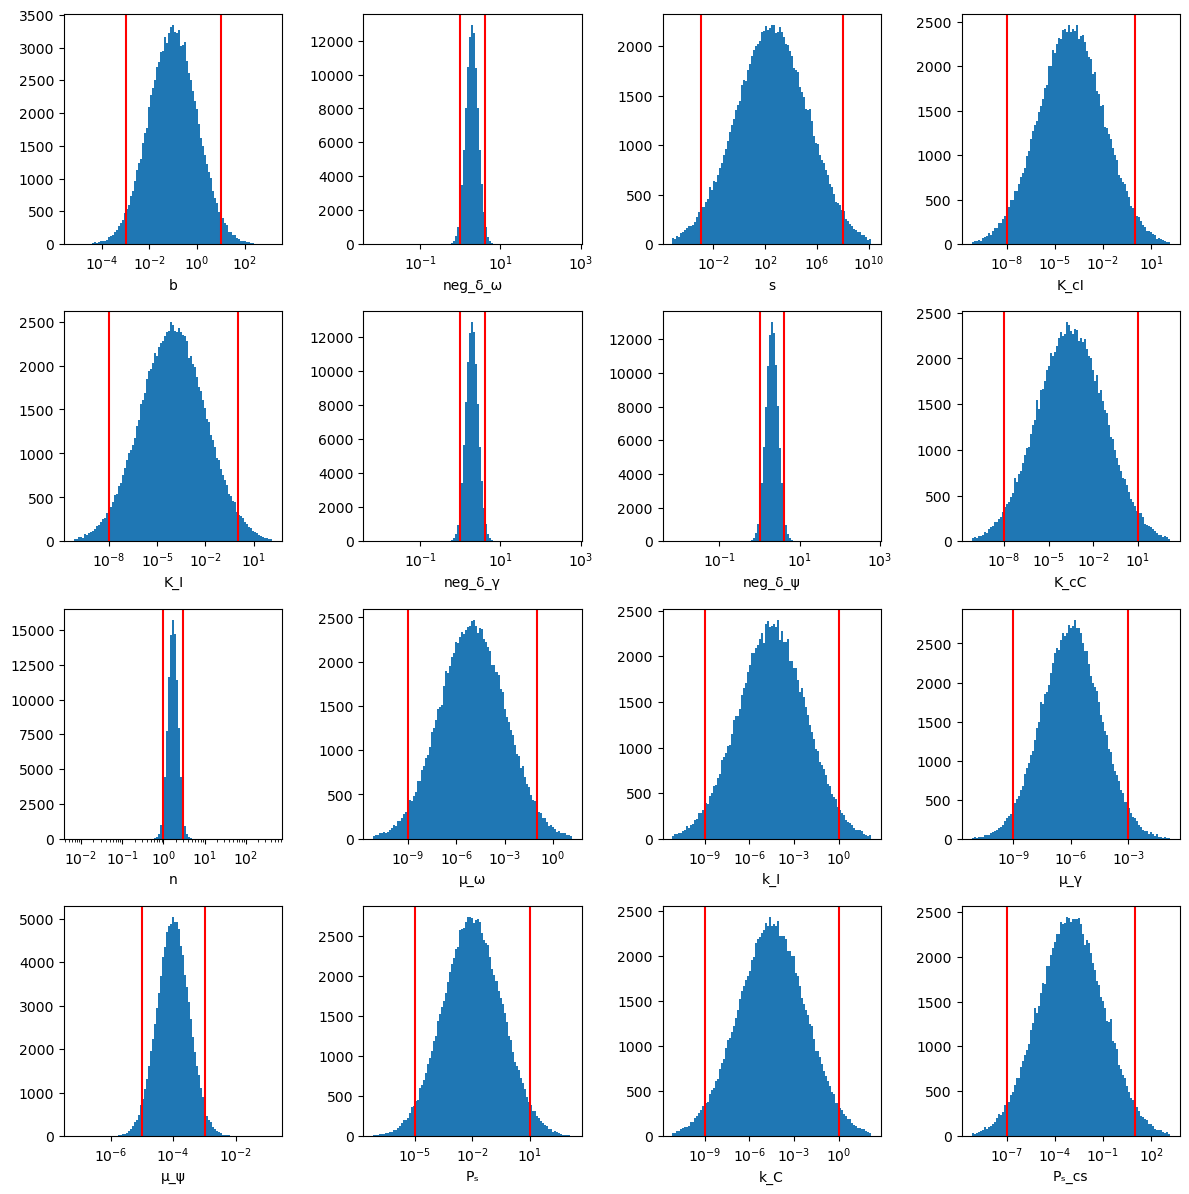

In [2]:
bounds_abs = Dict(
    :Pₛ     => (1e-5, 10),
    :Pₛ_cs  => (1e-7, 10),
    :K_I    => (1e-8, 1),
    :K_cI   => (1e-8, 1),
    :K_cC   => (1e-8, 10),
    :s      => (1e-3, 1e8),
    :b      => (1e-3, 10),
    :k_I    => (1e-9, 1),
    :k_C    => (1e-9, 1),
    :n      => (1, 3),
    :μ_γ    => (1e-9, 1e-3),
    :neg_δ_γ => (1, 4),
    :μ_ω    => (1e-9, 1e-1),
    :neg_δ_ω => (1, 4),
    :μ_ψ    => (1e-5, 1e-3),
    :neg_δ_ψ => (1, 4)
)

bounds_rel = Dict(
    :Pₛ     => (1e-5, 10),
    :Pₛ_cs  => (1e-7, 10),
    :K_I    => (1e-8, 1),
    :K_cI   => (1e-8, 1),
    :K_cC   => (1e-8, 10),
    :s      => (1e-3, 1e8),
    :b      => (1e-3, 10),
    :k_I    => (1e-9, 1),
    :k_C    => (1e-6, 1e3),
    :n      => (1, 3),
    :μ_γ    => (1e-6, 1),
    :neg_δ_γ => (1, 4),
    :μ_ω    => (1e-9, 1e-1),
    :neg_δ_ω => (1, 4),
    :μ_ψ    => (1e-5, 1e-3),
    :neg_δ_ψ => (1, 4)
)

# Compute histograms
data = Dict()
for (key, val) in bounds_abs
    mean = (log(val[1]) + log(val[2])) * 0.5
    sd = (log(val[2]) - log(val[1])) / (2 * 1.96)
    dist = LogNormal(mean, sd)
    data[key] = rand(dist, 100000)
end

matplotlib.pyplot.close()

fig, axs = subplots(4, 4, figsize=(12, 12))
# println(size(axs))
axs = vec(axs)
println(size(axs))

for (i, key) in enumerate(keys(bounds_abs))

    # Log bins
    bins = exp.(LinRange(log(bounds_abs[key][1])-5, log(bounds_abs[key][2])+5, 100))

    axs[i].hist(data[key], bins=bins)
    axs[i].axvline(bounds_abs[key][1], color="red")
    axs[i].axvline(bounds_abs[key][2], color="red")
    axs[i].set_xscale("log")
    axs[i].set_xlabel(key)
end

tight_layout()
gcf()

Next, random samples are taken from each prior and are used to run all models. After each run, a Dantigny triplet is fit to the germination curve and is recorded. For each spore density and inducer type in Ijadpanahsaravi et al. [3], the newly fitted Dantigny parameter distributions are compared to the documented ones, trying to identify whether certain parameter regions produce mismatching statistics.

The utility procedure below explores variations within a single parameter, using the mean values of the remaining parameters, and tests the non-linear squares fitting of the Dantigny triplets.

Dict{Any, Any}(:b => 0.10000000000000002, :σ_ψ => 4.9999999999999955e-5, :c₀_cs => 0.01, :K_I => 9.999999999999991e-5, :n => 1.7320508075688774, :μ_ψ => 9.999999999999991e-5, :μ_κ => 0.2, :μ_ω => 9.999999999999997e-6, :σ_ω => 4.999999999999999e-6, :Pₛ => 0.009999999999999995, :σ_ξ => 0.3, :μ_ξ => 2.65, :d_hp => 0.01, :s => 0.0010002327350563944, :σ_κ => 0.05, :k_I => 3.16227766016838e-5, :σ_γ => 5.000000000000002e-7, :k_C => 3.16227766016838e-5, :K_cI => 9.999999999999991e-5, :K_cC => 0.00031622776601683783, :μ_γ => 1.0000000000000004e-6, :Pₛ_cs => 0.0010000000000000002)
Dict{Any, Any}(:b => 0.10000000000000002, :σ_ψ => 4.9999999999999955e-5, :c₀_cs => 0.01, :K_I => 9.999999999999991e-5, :n => 1.7320508075688774, :μ_ψ => 9.999999999999991e-5, :μ_κ => 0.2, :μ_ω => 9.999999999999997e-6, :σ_ω => 4.999999999999999e-6, :Pₛ => 0.009999999999999995, :σ_ξ => 0.3, :μ_ξ => 2.65, :d_hp => 0.01, :s => 0.05113009102132699, :σ_κ => 0.05, :k_I => 3.16227766016838e-5, :σ_γ => 5.000000000000002e-7, :k_

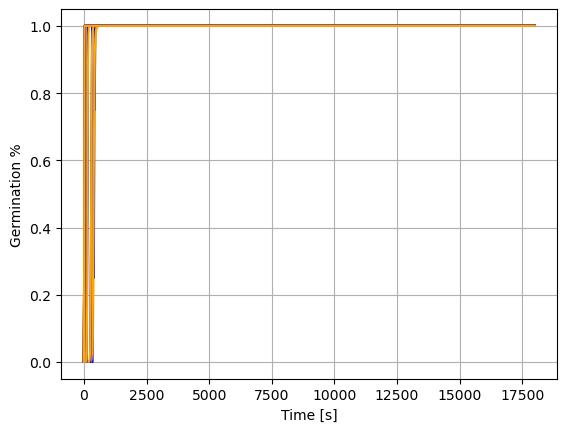

In [3]:
matplotlib.pyplot.close()

# Parameter sample
n_samples = 16
varied_param_key = :s
param_bounds = bounds_abs
varied_param = Dict()
non_varied_params = Dict()
for (key, val) in param_bounds
    mean = (log(val[1]) + log(val[2])) * 0.5
    if key == varied_param_key
        sd = (log(val[2]) - log(val[1])) / (2 * 1.96)
        dist = LogNormal(mean, sd)
        
        # println(collect(LinRange(val[1], val[2], n_samples)))
        samples = quantile.(dist, LinRange(0.025, 0.975, n_samples))

        # Transform sigmas
        if startswith(string(key), "neg_δ_")
            suffix = string(key)[end]
            mean_bnds_match = param_bounds[Symbol("μ_" * suffix)]
            mean_match = exp((log(mean_bnds_match[1]) + log(mean_bnds_match[2])) * 0.5)
            varied_param[Symbol("σ_" * suffix)] = mean_match .* exp(-samples)
        else
            varied_param[key] = samples
        end
    else
        # Transform sigmas
        if startswith(string(key), "neg_δ_")
            suffix = string(key)[end]
            mean_bnds_match = param_bounds[Symbol("μ_" * suffix)]
            mean_match = exp((log(mean_bnds_match[1]) + log(mean_bnds_match[2])) * 0.5)
            non_varied_params[Symbol("σ_" * suffix)] = mean_match .* exp(-mean)
            # println("transformed $(Symbol("σ_" * suffix)) to $(mean_match .* exp(-mean))")
        else
            non_varied_params[key] = exp(mean)
        end
    end
end

# Default parameters
def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)

# example_params = Dict(
#     :μ_ξ => 2.65,
#     :σ_ξ => 0.3,
#     :c₀_cs => 0.01,
#     :d_hp => 0.01,
#     :μ_κ => 0.2,
#     :σ_κ => 0.05,
#     :Pₛ => 5e-3,
#     :Pₛ_cs => 1e-5,
#     :μ_γ => 1e-3,
#     :σ_γ => 1e-4,
#     :μ_ω => 1e-3,
#     :σ_ω => 1e-4,
#     :s => 0.5,
#     :b => 0.95,
#     :μ_ψ => 0.5,
#     :σ_ψ => 0.01,
#     :K_cC => 0.01,
#     :K_cI => 0.01,
#     :K_I => 0.01,
#     :k_C => 0.1,
#     :n => 2,
#     :k_I => 1.0
# )

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 1000)
density_test = inverse_mL_to_cubic_um(1e5)

matplotlib.pyplot.close()
fig, ax = subplots()

for i in 1:n_samples

    # println(i)

    varied_param_sample = Dict(varied_param_key => varied_param[varied_param_key][i])
    sample_params = merge(varied_param_sample, non_varied_params, def_params)

    println(sample_params)

    p_out = compute_germination_response("feedback_combined_inducer_perm", times_eval, density_test, sample_params)

    (p_max, τ_g, ν), _ = fit_dantigny_to_germination_curve(p_out, times_eval)
    p_fit = dantigny.(times_eval, p_max, τ_g, ν)

    ax.plot(times_eval, p_out, color="blue")
    ax.plot(times_eval, p_fit, color="orange")
end

ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [16]:
t_max = 48 # hours

# Default parameters
def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)

# Load data
aliases, combination_IDs, descriptions = load_model_collection()
df_germination_rebuilt = parse_ijadpanahsaravi_data()
df_germination_rebuilt = filter(row -> row[1] != "Arg", df_germination_rebuilt) # Remove "Arg" from the dataset
dantigny_data, times, sources, densities, _, p_maxs, taus, nus = generate_dantigny_dataset(df_germination_rebuilt, t_max)

# println(df_germination_rebuilt)

# Generate (normalized) parameter samples
n_samples = 1024
n_dims = length(keys(bounds_abs))
sobol_pts = QuasiMonteCarlo.sample(n_samples, n_dims, SobolSample())

# Determine relative vs absolute threshold models
aliases_rel = ["0", "B", "Bi"]

# Precompute distributions
param_dists_abs = Dict()
for (key, val) in bounds_abs
    mean = (log(val[1]) + log(val[2])) * 0.5
    sd = (log(val[2]) - log(val[1])) / (2 * 1.96)
    param_dists_abs[key] = LogNormal(mean, sd)
end

param_dists_rel = Dict()
for (key, val) in bounds_rel
    mean = (log(val[1]) + log(val[2])) * 0.5
    sd = (log(val[2]) - log(val[1])) / (2 * 1.96)
    param_dists_rel[key] = LogNormal(mean, sd)
end

# Run samples
p_maxs = zeros(Float64, length(sources), length(densities), length(aliases), n_samples)
taus = zeros(Float64, length(sources), length(densities), length(aliases), n_samples)
nus = zeros(Float64, length(sources), length(densities), length(aliases), n_samples)
rmses = zeros(Float64, length(sources), length(densities), length(aliases), n_samples)
# p_max_means = zeros(Float64, length(sources), length(densities), length(aliases))
# p_max_sds = zeros(Float64, length(sources), length(densities), length(aliases))
# tau_means = zeros(Float64, length(sources), length(densities), length(aliases))
# tau_sds = zeros(Float64, length(sources), length(densities), length(aliases))
# nu_means = zeros(Float64, length(sources), length(densities), length(aliases))
# nu_sds = zeros(Float64, length(sources), length(densities), length(aliases))
# rmse_samples = zeros(Float64, length(sources), length(densities), length(aliases), n_samples)

for (i, src) in enumerate(sources) # iterate over carbon sources (exp. data)
    for (j, density) in enumerate(densities) # iterate over spore densities (exp. data)
        for m in 1:length(aliases)#eachindex(aliases) # iterate over models

            println("Running model $(aliases[m]) with source $src and density $density")

            # p_maxs_sample = zeros(n_samples)
            # taus_sample = zeros(n_samples)
            # nus_sample = zeros(n_samples)
            # rmse_sample = zeros(n_samples)

            for n in 1:n_samples # iterate over random parameter samples

                # Check if model uses absolute or relative bounds
                if aliases[m] in aliases_rel
                    sample_dists = param_dists_rel
                else
                    sample_dists = param_dists_abs
                end

                # Create parameter samples
                sample_params = Dict()
                for (k, key) in enumerate(keys(sample_dists))
                    sample_params[key] = quantile(sample_dists[key], 0.025 + 0.975*sobol_pts[k, n]) # limit to sampling to 95% within bounds
                end

                # Transform sigmas
                for key in keys(sample_dists)
                    if startswith(string(key), "neg_δ_")
                        suffix = string(key)[end]
                        sample_params[Symbol("σ_" * suffix)] = sample_params[Symbol("μ_" * suffix)] * exp(-sample_params[key])
                    end
                end

                # println(sample_params)
                # println(n)

                p_out = compute_germination_response(aliases[m], times, inverse_mL_to_cubic_um(density), merge(sample_params, def_params))
                (p_maxs[i, j, m, n], taus[i, j, m, n], nus[i, j, m, n]), rmses[i, j, m, n] = fit_dantigny_to_germination_curve(p_out, times)
                
            end

            # rmse_mask = rmse_sample .< 0.07 # only consider samples with low RMSE
            # p_max_means[i, j, m] = mean(p_maxs_sample[rmse_mask])
            # p_max_sds[i, j, m] = std(p_maxs_sample[rmse_mask])
            # tau_means[i, j, m] = mean(taus_sample[rmse_mask])
            # tau_sds[i, j, m] = std(taus_sample[rmse_mask])
            # nu_means[i, j, m] = mean(nus_sample[rmse_mask])
            # nu_sds[i, j, m] = std(nus_sample[rmse_mask])
            # rmse_samples[i, j, m, :] = rmse_sample
        end
    end
end

jldopen("../src/Data/prior_predictive_checks.jld2", "w") do file
    file["sources"] = sources
    file["densities"] = densities
    file["param_dists_rel"] = param_dists_rel
    file["param_dists_abs"] = param_dists_abs
    file["p_maxs"] = p_maxs
    file["taus"] = taus
    file["nus"] = nus
    file["rmses"] = rmses
end

Running model independent with source Ala and density 33333.333333333336
Running model feedback_combined_inducer_perm with source Ala and density 33333.333333333336
High RMSE: 0.03276862166836598
High RMSE: 0.0309270145433098
High RMSE: 0.055684172504548345
High RMSE: 0.05518786052061773
High RMSE: 0.03619733318268836
High RMSE: 0.03392302587046459
High RMSE: 0.038094584985318355
High RMSE: 0.04060307265223492
High RMSE: 0.039562311897398075
High RMSE: 0.0351093620969955
Running model feedback_combined_inducer_perm_thresh with source Ala and density 33333.333333333336
High RMSE: 0.04204238408154707
High RMSE: 0.03249832417319806
High RMSE: 0.04028219904644662
High RMSE: 0.05612325384050023
High RMSE: 0.03763259622660006
High RMSE: 0.039562311897398075
High RMSE: 0.03134978208122908
Running model feedback_combined_inducer_perm_thresh_inhibitor_signal with source Ala and density 33333.333333333336
High RMSE: 0.04642076935059159
High RMSE: 0.03276862166836598
High RMSE: 0.0417426052993729

Excessive output truncated after 524304 bytes.

2×4×58×1024 Array{Float64, 4}:
[:, :, 1, 1] =
 1.18178e-8  1.18178e-8  1.18178e-8  1.18178e-8
 1.18178e-8  1.18178e-8  1.18178e-8  1.18178e-8

[:, :, 2, 1] =
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9

[:, :, 3, 1] =
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9

;;; … 

[:, :, 56, 1] =
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9

[:, :, 57, 1] =
 1.18178e-8  1.18178e-8  1.18178e-8  1.18178e-8
 1.18178e-8  1.18178e-8  1.18178e-8  1.18178e-8

[:, :, 58, 1] =
 1.76477e-9  1.76477e-9  1.76477e-9  1.76477e-9
 1.76477e-9  1.76477e-9  1.76477e-9  1.76477e-9

[:, :, 1, 2] =
 0.00436973  0.00062976  8.63289e-6  4.83547e-9
 0.00436973  0.00062976  8.63289e-6  4.83547e-9

[:, :, 2, 2] =
 0.0286638  0.028742  0.028742  0.0283292
 0.0286638  0.028742  0.028742  0.0283292

[:, :, 3, 2] =
 0.0282872  0.0282872  0.0282872  0.0282872
 0.0282872  0.0

In [15]:
t_max = 48 # hours

# Default parameters
def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)

# Load data
aliases, combination_IDs, descriptions = load_model_collection()
df_germination_rebuilt = parse_ijadpanahsaravi_data()
df_germination_rebuilt = filter(row -> row[1] != "Arg", df_germination_rebuilt) # Remove "Arg" from the dataset
dantigny_data, times, sources, densities, _, p_maxs, taus, nus = generate_dantigny_dataset(df_germination_rebuilt, t_max)

example_params = Dict{Any, Any}(:b => 1.6085442340227263, :σ_ψ => 2.016916804067881e-5, :K_I => 1.289547617106889e-8, :n => 1.4291286964009715, :μ_ψ => 0.00024002950186128948, :neg_δ_ω => 1.5284472370580682, :neg_δ_γ => 2.20011413631179, :μ_ω => 3.171917673655506e-6, :Pₛ => 0.011501651404751328, :σ_ω => 6.879006278789664e-7, :s => 2.7177154188955105e6, :neg_δ_ψ => 2.4766067364574886, :k_I => 0.028112360212858865, :σ_γ => 6.468292163174515e-6, :k_C => 0.014106867447929234, :K_cI => 2.182718975169734e-5, :K_cC => 0.0005351599891834261, :μ_γ => 5.838308734092732e-5, :Pₛ_cs => 6.589765888683303e-6)
p_out = compute_germination_response("feedback_combined_inducer_perm_thresh_inhibitor_signal", times, inverse_mL_to_cubic_um(1e5), merge(example_params, def_params))

1000-element Vector{Float64}:
 0.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 ⋮
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0

## References

- [1] Xu, Y., Zhao, X., Glass, D.S., Absalan, F., Perlman, D.H., Broach, J.R., & Rabinowitz, J.D. (2012). Regulation of yeast pyruvate kinase by ultrasensitive allostery independent of phosphorylation. Molecular cell, 48 1, 52-62 .
- [2] Abeliovich, H. (2005). An empirical extremum principle for the hill coefficient in ligand-protein interactions showing negative cooperativity. Biophysical journal, 89 1, 76-9 .
- [3] Ijadpanahsaravi, Maryam, L. Basten Snoek, Wieke R. Teertstra and Han A. B. Wösten. “The impact of inter- and intra-species spore density on germination of the food spoilage fungus Aspergillus niger.” _International journal of food microbiology_ 410 (2023): 110495 .